In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt



#sm_path = "../data/smartmeter_per_meter_ALL_D1364_sp1.parquet"
sm_path = "../data/smartmeter_15min_all_by_transformer_20250801_20251101_['LPQ_Current_L1_AVG', 'LPQ_Current_L2_AVG', 'LPQ_Current_L3_AVG']_NEWMETH.parquet"


In [2]:
df_sm = pd.read_parquet(sm_path)

# Make sure timestamp is datetime and sorted
df_sm["ts"] = pd.to_datetime(df_sm["ts"])
df_sm = df_sm.sort_values(["substation_id", "ts"])


In [3]:
# --- Choose a current column to represent per-meter load ---
# I_total is safest because phases can be NaN for 1-phase meters.
col = "I_total"

# --- Capacity proxy: per-meter 95th percentile over the whole window ---
df=df_sm.copy()

s = (
    df_sm.groupby("meteringpointid")[col]
      .quantile(0.95)
      .rename("I95")
      .reset_index()
)


# --- Plot histogram of the capacity proxy ---
plt.figure(figsize=(8,4))
plt.hist(s["I95"], bins=50)
plt.xlabel("Per-meter 95th percentile current (A)")
plt.ylabel("Number of meters")
plt.title(f"Distribution of per-meter I95 (substation 1364, sp1)")
plt.tight_layout()
plt.show()

# Optional: log-scale y if there are a few very large meters
plt.figure(figsize=(8,4))
plt.hist(s["I95"], bins=50, log=True)
plt.xlabel("Per-meter 95th percentile current (A)")
plt.ylabel("Number of meters (log scale)")
plt.title(f"Distribution of per-meter I95 (log y) (substation 1364, sp1)")
plt.tight_layout()
plt.show()

KeyError: 'meteringpointid'

In [5]:
df["date"] = df["ts"].dt.date

daily_i95 = (
    df.groupby(["meteringpointid", "date"])[col]
      .quantile(0.95)
      .rename("I95_day")
      .reset_index()
)

s2 = (
    daily_i95.groupby("meteringpointid")["I95_day"]
             .median()
             .rename("I95_median_over_days")
             .reset_index()
)



# attach tegund per meter (take first non-null)
meta = (df.groupby("meteringpointid")["tegund"]
          .agg(lambda x: x.dropna().iloc[0] if x.dropna().size else np.nan)
          .reset_index())

s_plot = s.merge(meta, on="meteringpointid", how="left")

for t, g in s_plot.groupby("tegund"):
    plt.figure(figsize=(8,4))
    plt.hist(g["I95"], bins=40)
    plt.xlabel("Per-meter I95 (A)")
    plt.ylabel("Number of meters")
    plt.title(f"I95 distribution — tegund = {t}")
    plt.tight_layout()
    plt.show()


KeyError: 'meteringpointid'

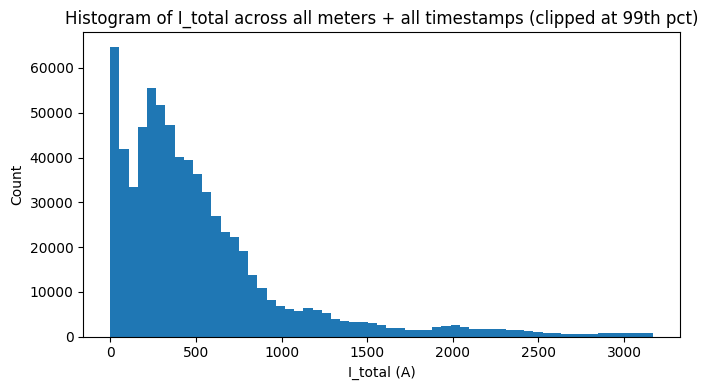

In [14]:
import numpy as np
import matplotlib.pyplot as plt

col = "I_total"

df = df_sm.copy()

# clean
vals = df[col].dropna().to_numpy()
vals = vals[vals >= 0]

# pick bins (simple + robust)
x_max = np.quantile(vals, 0.99)          # clip extreme tail for readability
bins = np.linspace(0, x_max, 60)

plt.figure(figsize=(7,4))
plt.hist(vals[vals <= x_max], bins=bins)
plt.xlabel(f"{col} (A)")
plt.ylabel("Count")
plt.title(f"Histogram of {col} across all meters + all timestamps (clipped at 99th pct)")
plt.tight_layout()
plt.show()

In [15]:
substation_stats = (
    df_sm
    .groupby("substation_id")
    .agg(
        mean_I_a=("I_a", "mean"),
        mean_I_b=("I_b", "mean"),
        mean_I_c=("I_c", "mean"),
        mean_I_total=("I_total", "mean"),
        max_I_total=("I_total", "max"),
        mean_per_completed=("per_completed", "mean"),
        n_samples=("ts", "count"),
    )
    .reset_index()
)

substation_stats.head()


,substation_id,mean_I_a,mean_I_b,mean_I_c,mean_I_total,max_I_total,mean_per_completed,n_samples
0,6,248.465451,247.492300,233.284541,729.242293,1118.47,0.146789,8833
1,29,292.869888,268.811557,273.399543,835.080988,2227.36,0.103448,8833
2,55,371.950881,304.095805,283.005948,959.052634,2596.61,0.624688,17666
3,74,148.517955,136.263690,125.768338,410.549983,891.50,0.412500,17666
4,76,241.485102,201.678887,166.515516,609.679505,994.54,0.375839,8833


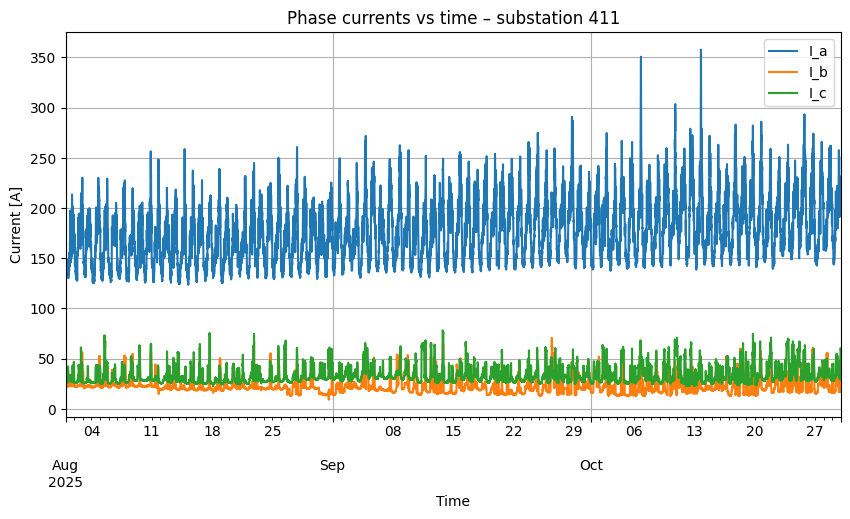

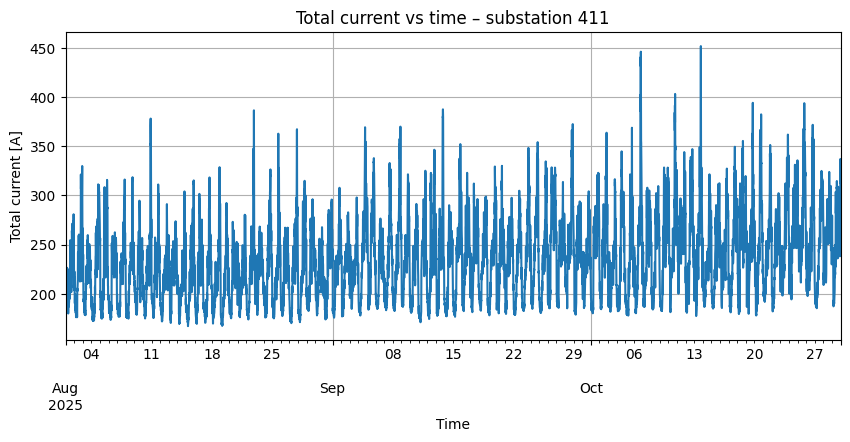

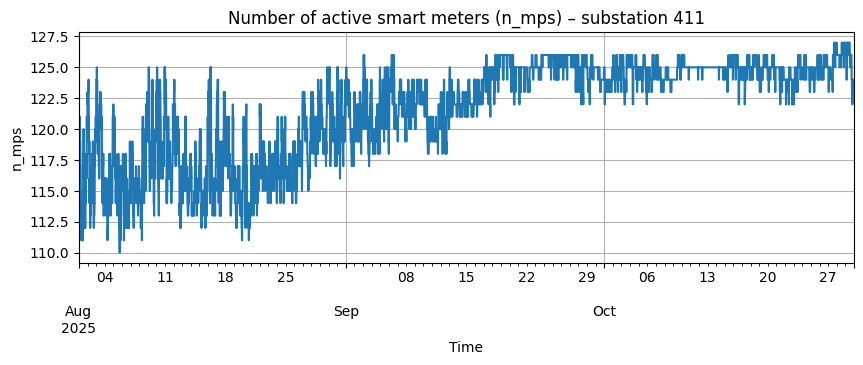

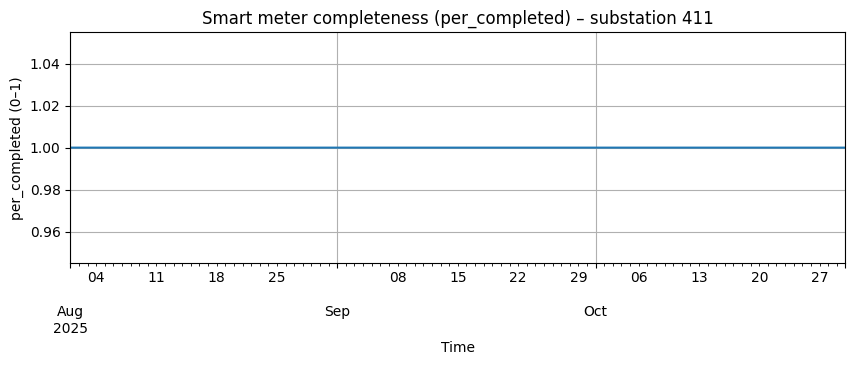

avg total current: 235.00828530092593


In [7]:
sub_id = 411  # <-- change this
trafo_id = "sp1"
days_to_plot = 90

df_one = df_sm[(df_sm["substation_id"] == sub_id) & (df_sm["transformer"] == trafo_id)].copy()
df_one = df_one.sort_values("ts").set_index("ts")

if days_to_plot is not None :
    start_time = df_one.index.min()
    end_time = start_time + pd.Timedelta(days=days_to_plot)
    df_one = df_one[(df_one.index >= start_time) & (df_one.index < end_time)]

# ---- Phase currents ----
df_one[["I_a", "I_b", "I_c"]].plot(figsize=(10, 5))
plt.title(f"Phase currents vs time – substation {sub_id}")
plt.xlabel("Time")
plt.ylabel("Current [A]")
plt.grid(True)
plt.show()

# ---- Total current ----
df_one["I_total"].plot(figsize=(10, 4))
plt.title(f"Total current vs time – substation {sub_id}")
plt.xlabel("Time")
plt.ylabel("Total current [A]")
plt.grid(True)
plt.show()

# ---- n_mps ----
df_one["n_mps"].plot(figsize=(10, 3))
plt.title(f"Number of active smart meters (n_mps) – substation {sub_id}")
plt.xlabel("Time")
plt.ylabel("n_mps")
plt.grid(True)
plt.show()

# ---- per_completed ----
df_one["per_completed"].plot(figsize=(10, 3))
plt.title(f"Smart meter completeness (per_completed) – substation {sub_id}")
plt.xlabel("Time")
plt.ylabel("per_completed (0–1)")
plt.grid(True)
plt.show()

print("avg total current:", df_one["I_total"].mean())


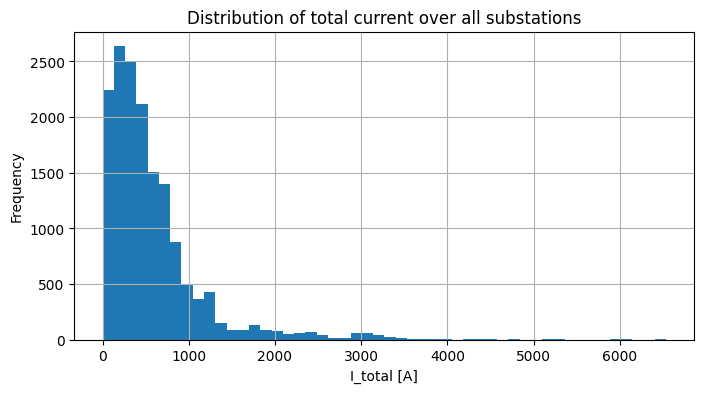

In [ ]:
df_sm["I_total"].plot(kind="hist", bins=50, figsize=(8, 4))
plt.title("Distribution of total current over all substations")
plt.xlabel("I_total [A]")
plt.grid(True)
plt.show()


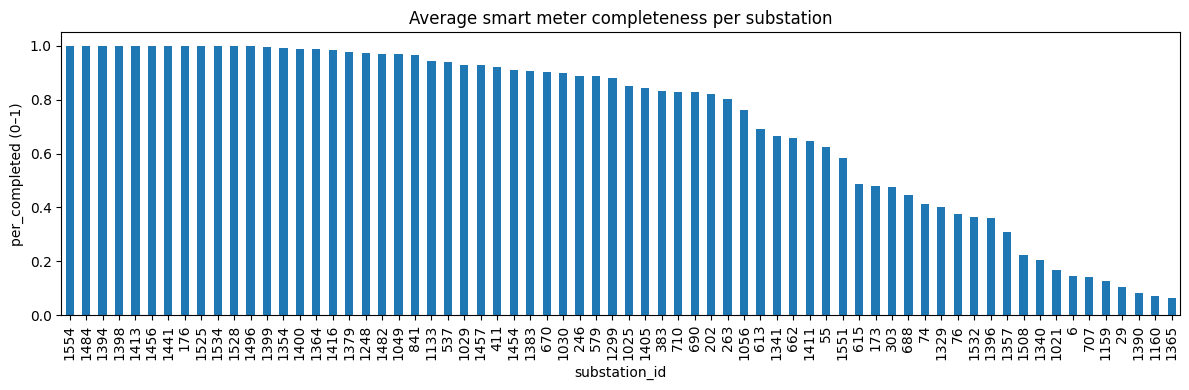

In [ ]:
avg_comp = (
    df_sm.groupby("substation_id")["per_completed"]
    .mean()
    .sort_values(ascending=False)
)

avg_comp.plot(kind="bar", figsize=(12, 4))
plt.title("Average smart meter completeness per substation")
plt.ylabel("per_completed (0–1)")
plt.xlabel("substation_id")
plt.tight_layout()
plt.show()


Cutoff = 0.90: keeping 31 of 68 substations


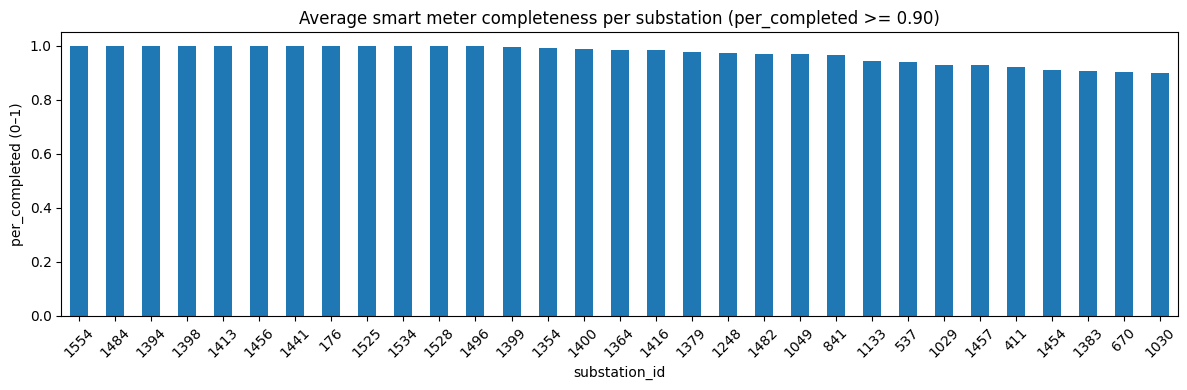

In [ ]:
# Set cutoff threshold (0.0 - 1.0). Substations with avg per_completed < cutoff will be excluded.
cutoff = 0.9

filtered = avg_comp[avg_comp >= cutoff]

print(f"Cutoff = {cutoff:.2f}: keeping {len(filtered)} of {len(avg_comp)} substations")
if filtered.empty:
    print("No substations meet the cutoff. Lower the threshold.")
else:
    ax = filtered.plot(kind="bar", figsize=(12, 4))
    ax.set_title(f"Average smart meter completeness per substation (per_completed >= {cutoff:.2f})")
    ax.set_ylabel("per_completed (0–1)")
    ax.set_xlabel("substation_id")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Active Power

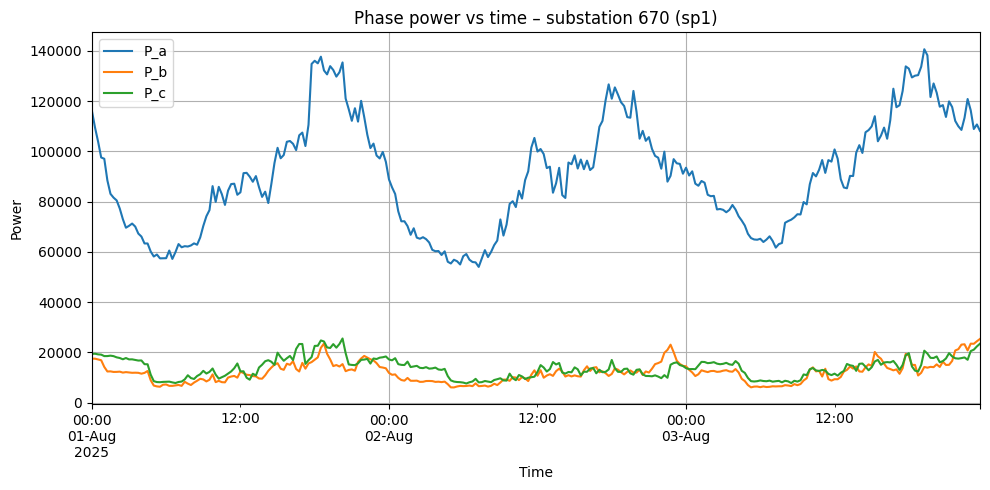

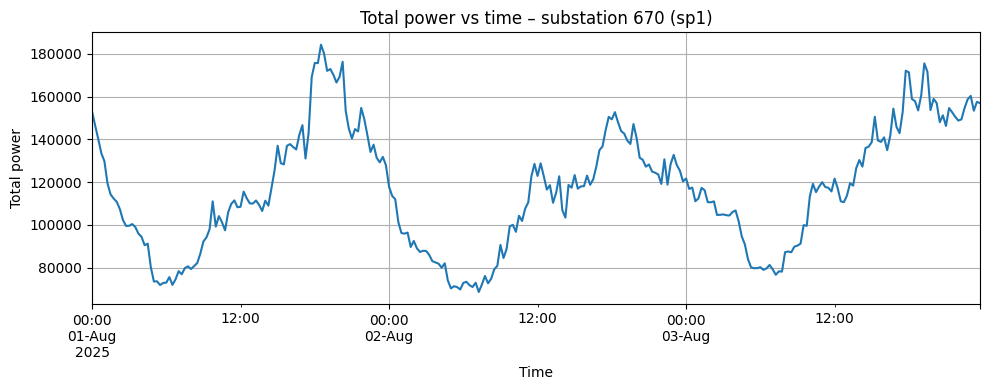

In [17]:

sub_id = 670
trafo_id = "sp1"
days_to_plot = 3

# Rebuild df_one for THIS (substation, transformer)
df_one = df_sm[(df_sm["substation_id"] == sub_id) & (df_sm["transformer"] == trafo_id)].copy()
if df_one.empty:
    raise ValueError(f"No data found for substation_id={sub_id}, transformer={trafo_id}")

df_one = df_one.sort_values("ts").set_index("ts")

if days_to_plot is not None:
    start_time = df_one.index.min()
    end_time = start_time + pd.Timedelta(days=days_to_plot)
    df_one = df_one[(df_one.index >= start_time) & (df_one.index < end_time)]

# ---- Power per phase ----
power_cols = ["P_a", "P_b", "P_c"]
missing = [c for c in power_cols if c not in df_one.columns]
if missing:
    raise KeyError(f"Missing power columns in df_one: {missing}")

df_one[power_cols].plot(figsize=(10, 5))
plt.title(f"Phase power vs time – substation {sub_id} ({trafo_id})")
plt.xlabel("Time")
plt.ylabel("Power")
plt.grid(True)
plt.tight_layout()
plt.show()

# ---- Total power ----
if "P_total" not in df_one.columns:
    raise KeyError("Missing column in df_one: P_total")

df_one["P_total"].plot(figsize=(10, 4))
plt.title(f"Total power vs time – substation {sub_id} ({trafo_id})")
plt.xlabel("Time")
plt.ylabel("Total power")
plt.grid(True)
plt.tight_layout()
plt.show()


### Apparant Power

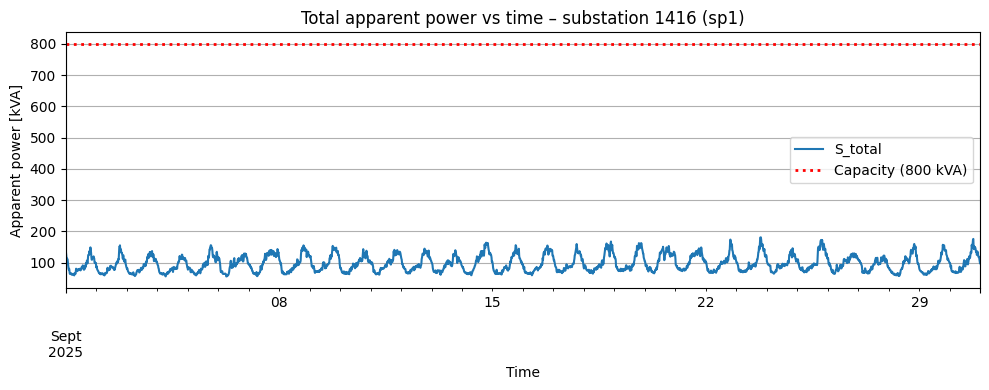

In [26]:
# COMMAND ----------
import pandas as pd
import matplotlib.pyplot as plt

sub_id = 1416
trafo_id = "sp1"

date_from = "2025-09-01"
date_to   = "2025-10-01"

capacity_kVA = 800  # transformer capacity line

# Rebuild df_one for THIS (substation, transformer)
df_one = df_sm[(df_sm["substation_id"] == sub_id) & (df_sm["transformer"] == trafo_id)].copy()
if df_one.empty:
    raise ValueError(f"No data found for substation_id={sub_id}, transformer={trafo_id}")

df_one = df_one.sort_values("ts").set_index("ts")

# Apply chosen time window
start_time = pd.to_datetime(date_from)
end_time   = pd.to_datetime(date_to)

df_one = df_one[(df_one.index >= start_time) & (df_one.index < end_time)]
if df_one.empty:
    raise ValueError(f"No data in the selected time window: {start_time} to {end_time}")

# ---- Apparent power (total only) ----
if "S_total" not in df_one.columns:
    raise KeyError("Missing column in df_one: S_total")

# Convert VA -> kVA
S_total_kVA = df_one["S_total"] / 1e3

# Plot
ax = S_total_kVA.plot(figsize=(10, 4), label="S_total")
ax.axhline(capacity_kVA, color="red", linestyle=":", linewidth=2, label=f"Capacity ({capacity_kVA} kVA)")

plt.title(f"Total apparent power vs time – substation {sub_id} ({trafo_id})")
plt.xlabel("Time")
plt.ylabel("Apparent power [kVA]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
